<a href="https://colab.research.google.com/github/Razanhus/Razan-mini-projects/blob/main/Physics_%26_Space_Data_Analysis_with_Python_%F0%9F%9A%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## تحليل بيانات الفيزياء والفضاء باستخدام Python 🚀

### 🧐 نظرة عامة على المشروع

يقدم هذا المشروع **تحليلًا استكشافيًا أوليًا (EDA)** لبيانات **الكواكب الخارجية (Exoplanets)** المكتشفة بواسطة **تلسكوب كيبلر الفضائي التابع لوكالة ناسا**. يهدف المشروع إلى التعامل مع بيانات فلكية حقيقية باستخدام لغة **Python**، وتحليل توزيع أحجام الكواكب الخارجية مقارنةً بحجم كوكب الأرض.

### 🛠 الأدوات والمكتبات المستخدمة

* **لغة البرمجة:** Python 3
* **تحليل البيانات:** pandas
* **التصور البياني:** matplotlib

### 📊 خطوات التحليل

1. تحميل بيانات الكواكب الخارجية من أرشيف وكالة ناسا وتنظيفها.
2. استكشاف بنية البيانات باستخدام الأمر **`df.head()`**.
3. رسم وتحليل توزيع أنصاف أقطار الكواكب الخارجية مقارنةً بنصف قطر الأرض باستخدام الرسوم البيانية.



In [16]:
import pandas as pd
import matplotlib.pyplot as plt



**تنزيل بيانات الكواكب الخارجية من وكالة ناسا**


In [6]:
url = "/content/physics-space-data-analysis-with-python.ipynb"

In [12]:
url = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=select+pl_name,pl_orbper,pl_rade,pl_eqt+from+pscomppars+where+pl_rade+is+not+null&format=csv"

In [13]:
df= pd.read_csv(url)

In [14]:
print("First Exoplanets")
print(df.head())

First Exoplanets
                 pl_name    pl_orbper    pl_rade  pl_eqt
0               XO-2 S d  4696.000000  13.000000  110.98
1          Kepler-1808 b    23.340401   3.025113  601.00
2           Kepler-418 b    86.678560  13.450000  434.00
3           Kepler-249 d    15.368459   1.570000  332.00
4  OGLE-2017-BLG-0364L b          NaN  10.300000     NaN


# رسم توزيع أنصاف أقطار الكواكب الخارجية

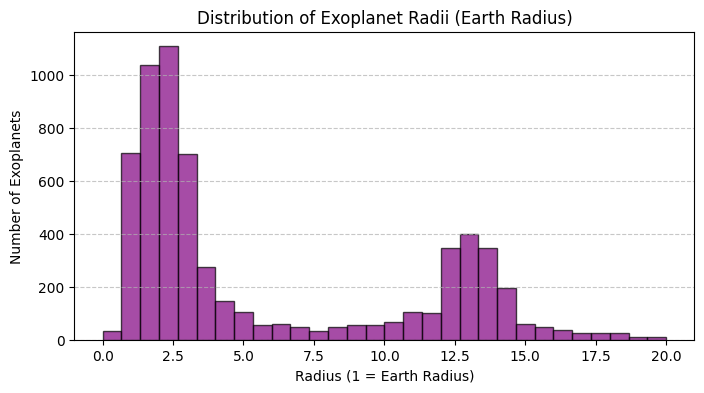

In [17]:
plt.figure(figsize=(8, 4))
plt.hist(df['pl_rade'].dropna(), bins=30, range=(0, 20), color='purple', edgecolor='black', alpha=0.7)
plt.title('Distribution of Exoplanet Radii (Earth Radius)')
plt.xlabel('Radius (1 = Earth Radius)')
plt.ylabel('Number of Exoplanets')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# تمييز نطاق درجة الحرارة المحتمل الصالح للحياة (تقريبًا من 200 إلى 300 كلفن)

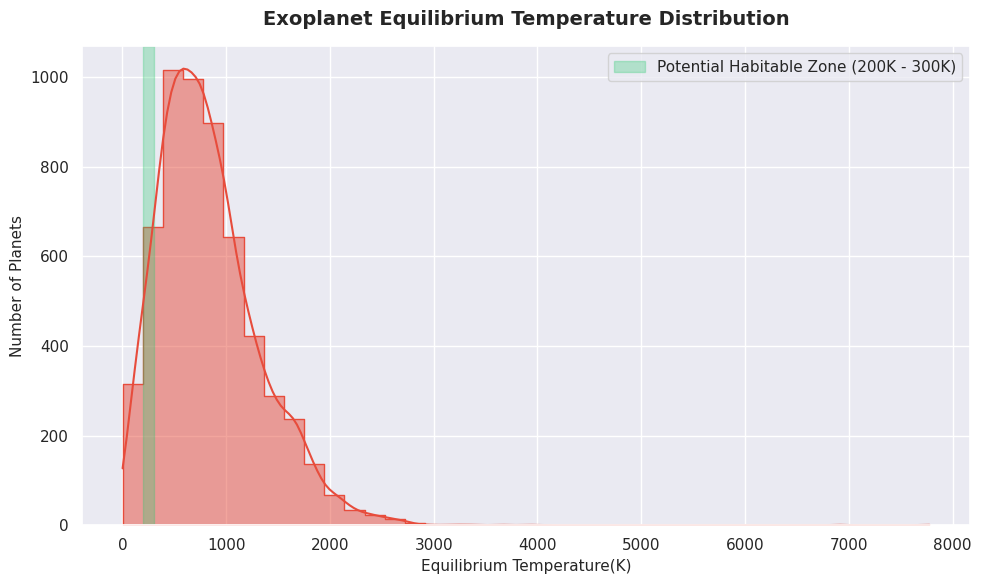

In [29]:
import seaborn as sns
sns.set_theme(style="darkgrid")
plt.figure(figsize=(10,6))


sns.histplot(
    data=df['pl_eqt'].dropna(),
    kde=True,
    color='#e74c3c',
    bins=40,
    element="step"
)

plt.axvspan(200, 300, color='#2ecc71', alpha=0.3, label='Potential Habitable Zone (200K - 300K)') #النطاق الصالح المحتمل للحياة
plt.title('Exoplanet Equilibrium Temperature Distribution', fontsize=14, fontweight='bold', pad=15) #توزيع درجة حرارة الاتزان للكواكب الخارجية,
plt.xlabel('Equilibrium Temperature(K)', fontsize=11) #درجة حرارة الاتزان
plt.ylabel('Number of Planets', fontsize=11) #عدد الكواكب'

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

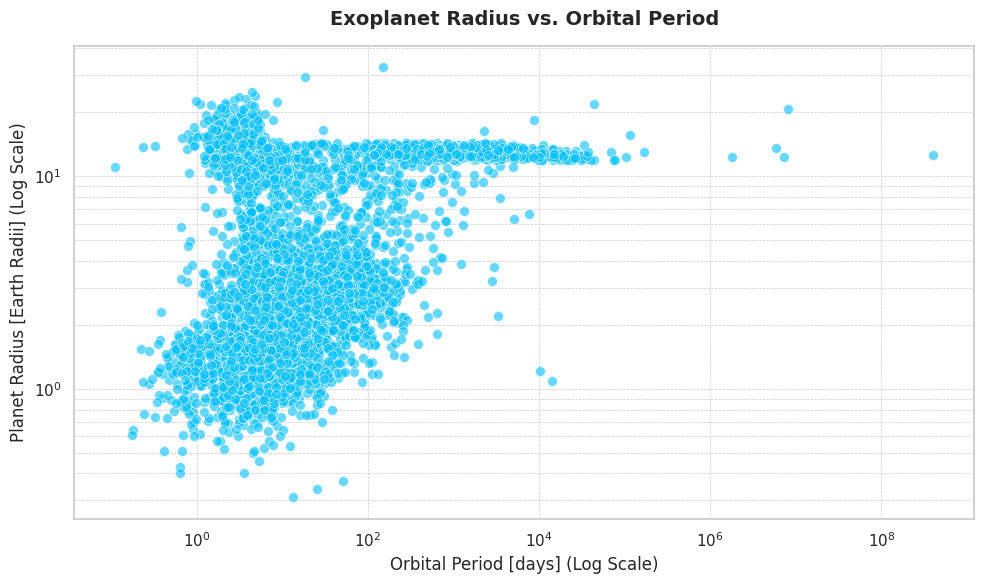

In [31]:
# تنظيف البيانات وحذف القيم المفقودة لضمان دقة الرسم البياني

data_clean = df.dropna(subset=['pl_orbper', 'pl_rade'])

sns.set_theme(style='whitegrid')
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=data_clean,
    x='pl_orbper',
    y='pl_rade',
    alpha=0.6,
    color='deepskyblue',
    edgecolor='w',
    s=50
)
# استخدام مقياس لوغاريتمي لتحسين عرض نطاق القيم الواسع

plt.xscale('log')
plt.yscale('log')

plt.title('Exoplanet Radius vs. Orbital Period', fontsize=14, fontweight='bold', pad=15)#نصف قطر الكواكب الخارجية مقابل الفترة المدارية
plt.xlabel('Orbital Period [days] (Log Scale)', fontsize=12) #الفترة المدارية (بالأيام)
plt.ylabel('Planet Radius [Earth Radii] (Log Scale)', fontsize=12) #**نصف قطر الكوكب (بوحدة نصف قطر الأرض)**



plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.tight_layout()
plt.show()


In [39]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix



Model Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

   Gas Giant       1.00      1.00      1.00       553
 Super-Earth       1.00      1.00      1.00       483
      Terran       1.00      1.00      1.00       105

    accuracy                           1.00      1141
   macro avg       1.00      1.00      1.00      1141
weighted avg       1.00      1.00      1.00      1141



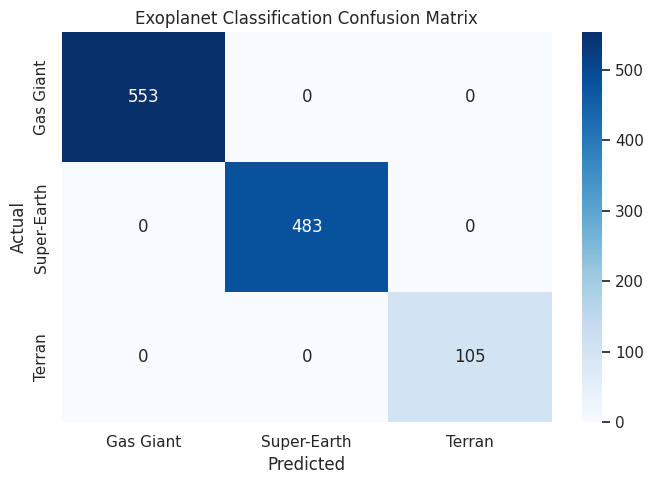

In [52]:
from numpy.random import choice
#  إعداد المتغيرات (Features) والمتغير المستهدف (Target) مع التحقق ديناميكيًا من الأعمدة المتوفرة
possible_features = ['pl_orbper', 'pl_rade', 'pl_eqt', 'pl_bmassj', 'pl_masse']
features = [col for col in possible_features if col in df.columns]

if 'pl_rade' not in features:
    features = ['pl_orbper', 'pl_rade', 'pl_eqt']
df_ml = df.dropna(subset=features).copy()

conditions = [
    (df_ml['pl_rade'] < 1.2),
    (df_ml['pl_rade'] >= 1.2) & (df_ml['pl_rade'] <= 3.0),
    (df_ml['pl_rade'] > 3.0)]

choices = ['Terran', 'Super-Earth', 'Gas Giant']
df_ml['planet_type'] = np.select(conditions, choices,
                                 default='Gas Giant')


X = df_ml[features]
y = df_ml['planet_type']

# 2. Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Model Training
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {acc * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Exoplanet Classification Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

🎯 الخاتمة 😇

كان تنفيذ هذا المشروع تجربة ممتعة، حيث جمع بين الفيزياء وPython وعلوم البيانات لاستكشاف الكواكب الخارجية.

🧐 أهم ما تعلمته:

🔭 معظم الكواكب المكتشفة حارة بسبب سهولة رصد الكواكب القريبة من نجومها.
📊 استخدام المقياس اللوغاريتمي أوضح الفرق بين الكواكب الصخرية الصغيرة والعمالقة الغازية.
🤖 أظهر نموذج Random Forest أهمية اختيار الخصائص الفيزيائية المناسبة لتحقيق تصنيف دقيق.

🚀 الخطوة القادمة:
إضافة بيانات الإشعاع النجمي لتحسين تحديد حدود النطاق الصالح للحياة (Habitable Zone) بدقة أكبر.